In [15]:
import os
from pathlib import Path

# Ensure working directory is the project root, not the notebooks/ folder
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())

Working directory: /Users/nateseluga/Downloads/Shot-Value-Machine-Learning


In [16]:
import pandas as pd

df_clean = pd.read_csv("data/processed/shot_logs_cleaned_engineered.csv")

# define feature columns
features = [
    "shot_dist",              # distance from basket
    "close_def_dist",         # defender distance
    "shot_clock",             # time remaining on shot clock
    "dribbles",               # number of dribbles before shot
    "touch_time",             # time holding the ball before shot
    "game_clock_pct",         # normalized game time
    "def_dist_x_shot_dist",   # interaction: defense × distance
    "shot_dist_squared"       # nonlinear effect of distance
]

# create feature matrix (X) and target vector (y)
X = df_clean[features]
y = df_clean["made"]

# check dimensions (rows = shots, columns = features)
print("X shape:", X.shape)
print("y shape:", y.shape)

# preview data
X.head()

X shape: (122203, 8)
y shape: (122203,)


,shot_dist,close_def_dist,shot_clock,dribbles,touch_time,game_clock_pct,def_dist_x_shot_dist,shot_dist_squared
0,7.7,1.3,10.8,2,1.9,0.095833,10.01,59.29
1,28.2,6.1,3.4,0,0.8,0.019444,172.02,795.24
2,17.2,3.4,10.3,2,1.9,0.490972,58.48,295.84
3,3.7,1.1,10.9,2,2.7,0.440278,4.07,13.69
4,18.4,2.6,9.1,2,4.4,0.343750,47.84,338.56


In [17]:
from sklearn.model_selection import train_test_split

# split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42  # ensures reproducibility
)

# verify split sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (97762, 8)
X_test shape: (24441, 8)


In [18]:
from sklearn.preprocessing import StandardScaler

# standardize features to ensure comparable scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (97762, 8)
X_test_scaled shape: (24441, 8)


In [19]:
from sklearn.linear_model import LogisticRegression

# train logistic regression to learn relationship between features and shot outcome
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [20]:
# extract learned coefficients for each feature
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": log_reg.coef_[0]
})

# sort by coefficient value (largest positive → largest negative)
coef_df = coef_df.sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
1,close_def_dist,0.923020
7,shot_dist_squared,0.848331
3,dribbles,0.081976
2,shot_clock,0.076471
5,game_clock_pct,0.003023
4,touch_time,-0.150928
6,def_dist_x_shot_dist,-0.907067
0,shot_dist,-0.984467


In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# generate predictions and probabilities on the test set to evaluate model performance
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# compute standard classification metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Log Loss:", log_loss(y_test, y_prob))

Accuracy: 0.609385868008674
ROC AUC: 0.6279494296783984
Log Loss: 0.6565953590258984


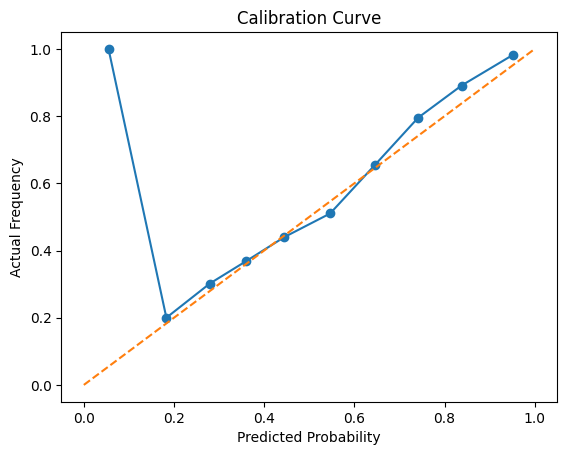

In [22]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# compare predicted probabilities to observed make rates across probability bins
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Frequency")
plt.title("Calibration Curve")
plt.show()

In [23]:
# compare to naive baseline (predict mean for all shots)
baseline_prob = y_train.mean()
baseline_probs = [baseline_prob] * len(y_test)

print("Naive Log Loss:", log_loss(y_test, baseline_probs))
print("Model Log Loss:", log_loss(y_test, y_prob))

Naive Log Loss: 0.6895352548927419
Model Log Loss: 0.6565953590258984


Our logistic regression slightly outperforms a naive model which simple predicts every shot at the mean, suggesting that our model does somewhat capture the strength of a shot. However, the improvement is small, indicating we likely need stronger features beyond defender distance, shot clock and distance to the basket. To improve our model, we will determine what exactly it effectively captures and what it still lacks, hopefully allowing us to better classify shot types and improve predictive accuracy.

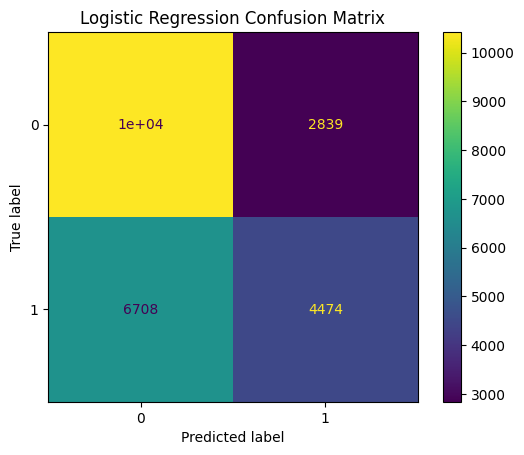

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# visualize classification results at the default 0.5 threshold
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

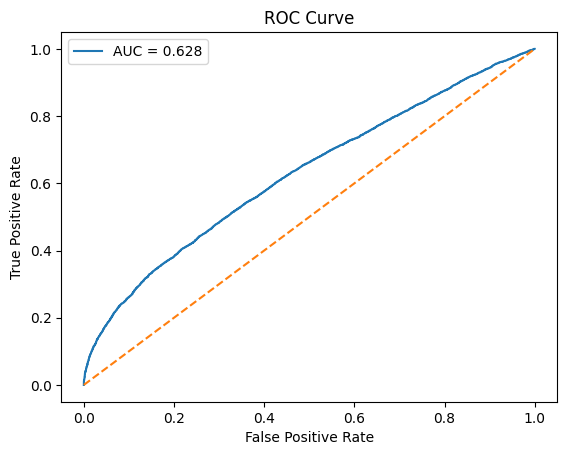

In [25]:
from sklearn.metrics import roc_curve, auc

# plot true positive rate against false positive rate across thresholds
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

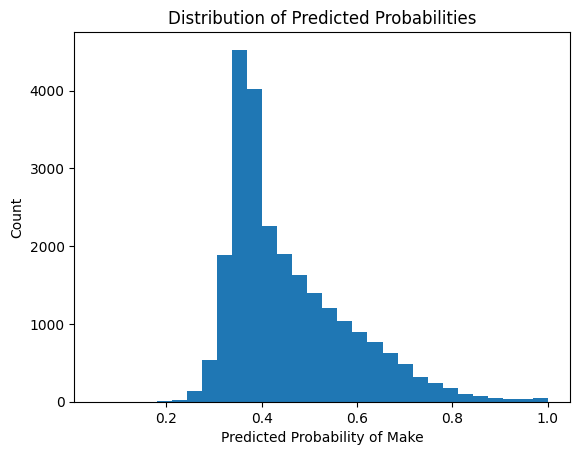

In [26]:
# inspect how confident the model is in its predicted probabilities
plt.hist(y_prob, bins=30)
plt.xlabel("Predicted Probability of Make")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")
plt.show()

The diagnostic plots suggest that our initial model struggles to clearly separate high and low quality shots based on the included features. The confusion matrix identifies a particularly high number of false negatives, meaning our model is not able to confidently identify made shots. The ROC curve a moderately useful predictive accuracy, with only a 0.63 AUC. The predicted probability graph may be the most useful, showing that our model predicts probability very modestly, with most of the predictions tightly clustered at around a 50% confidence. Overall, our findings suggest that we need to implement more telling features or possibly use a more flexible model class to more accurately determine inherently strong shots.